In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Görünüm ayarları
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Veriyi yükleme
df = pd.read_csv("advertising.csv")

# Değişkenleri tanımlama ve NumPy dizisine çevirme
X = df["Radio"].values
Y = df["Sales"].values

# 1. Cost Function (Maliyet Fonksiyonu)
def cost_function(Y, b, w, X):
    m = len(Y)
    sse = 0
    for i in range(0, m):
        y_hat = b + w * X[i]
        y = Y[i]
        sse += (y_hat - y) ** 2
    mse = sse / m
    return mse

# 2. Update Weights (Ağırlık Güncelleme)
def update_weights(Y, b, w, X, learning_rate):
    m = len(Y)
    b_deriv_sum = 0
    w_deriv_sum = 0
    for i in range(0, m):
        y_hat = b + w * X[i]
        y = Y[i]
        b_deriv_sum += (y_hat - y)
        w_deriv_sum += (y_hat - y) * X[i]

    new_b = b - (learning_rate * 1 / m * b_deriv_sum)
    new_w = w - (learning_rate * 1 / m * w_deriv_sum)
    return new_b, new_w

# 3. Train Fonksiyonu
def train(Y, initial_b, initial_w, X, learning_rate, num_iters):
    print("Starting gradient descent at b = {0}, w = {1}, mse = {2}".format(
        initial_b, initial_w, cost_function(Y, initial_b, initial_w, X)))

    b = initial_b
    w = initial_w
    cost_history = []

    for i in range(num_iters):
        b, w = update_weights(Y, b, w, X, learning_rate)
        mse = cost_function(Y, b, w, X)
        cost_history.append(mse)

        if i % 1000 == 0: # Her 1000 adımda bir yazdır
            print("iter={:d}    b={:.2f}    w={:.4f}    mse={:.4f}".format(i, b, w, mse))

    print("After {0} iterations b = {1}, w = {2}, mse = {3}".format(
        num_iters, b, w, cost_function(Y, b, w, X)))
    return cost_history, b, w

# Hiperparametreler ve Çalıştırma
learning_rate = 0.001
initial_b = 0.001
initial_w = 0.001
num_iters = 10000

cost_history, b, w = train(Y, initial_b, initial_w, X, learning_rate, num_iters)


Starting gradient descent at b = 0.001, w = 0.001, mse = 239.04442380682534
iter=0    b=0.02    w=0.4470    mse=15.3492
iter=1000    b=1.43    w=0.4676    mse=7.8732
iter=2000    b=2.56    w=0.4339    mse=5.2986
iter=3000    b=3.47    w=0.4069    mse=3.6510
iter=4000    b=4.19    w=0.3853    mse=2.5967
iter=5000    b=4.77    w=0.3681    mse=1.9220
iter=6000    b=5.24    w=0.3543    mse=1.4903
iter=7000    b=5.61    w=0.3432    mse=1.2140
iter=8000    b=5.90    w=0.3344    mse=1.0372
iter=9000    b=6.14    w=0.3273    mse=0.9240
After 10000 iterations b = 6.331197013549171, w = 0.3216924717579845, mse = 0.8516888134259213


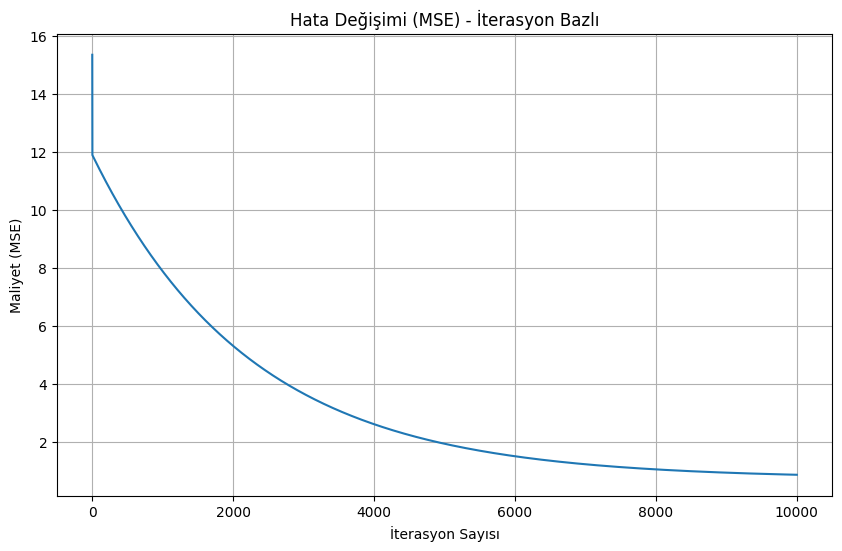

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(cost_history)
plt.title("Hata Değişimi (MSE) - İterasyon Bazlı")
plt.xlabel("İterasyon Sayısı")
plt.ylabel("Maliyet (MSE)")
plt.grid(True)
plt.show()

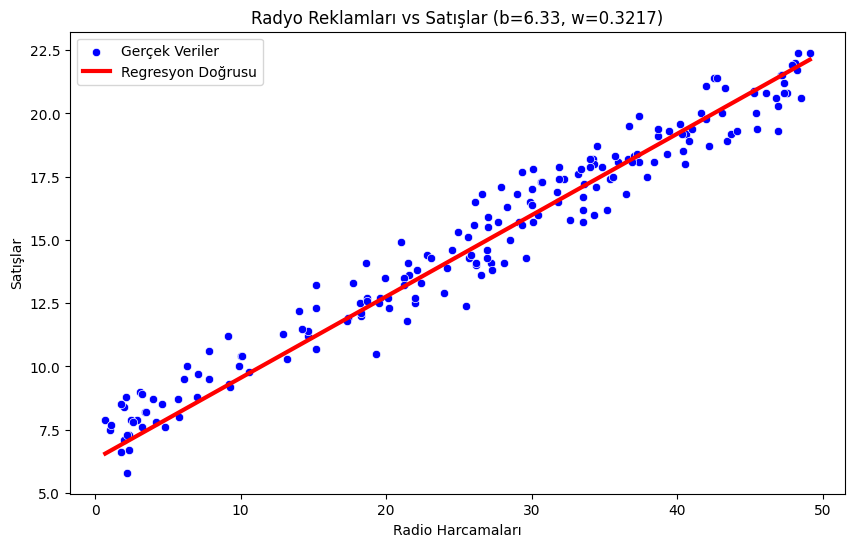

In [ ]:
# Tahmin çizgisi için x değerleri oluşturma
x_range = np.linspace(X.min(), X.max(), 100)
y_range = b + w * x_range

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=Y, color="blue", label="Gerçek Veriler")
plt.plot(x_range, y_range, color="red", linewidth=3, label="Regresyon Doğrusu")
plt.title(f"Radyo Reklamları vs Satışlar (b={b:.2f}, w={w:.4f})")
plt.xlabel("Radio Harcamaları")
plt.ylabel("Satışlar")
plt.legend()
plt.show()

In [ ]:
# Tahminlerin hesaplanması
y_pred = b + w * X

# İlk 10 gözlem için karşılaştırma tablosu
comparison_df = pd.DataFrame({
    'Gerçek Satış': Y,
    'Tahmin Edilen': y_pred,
    'Hata (Fark)': Y - y_pred,
    'Karesel Hata': (Y - y_pred)**2
})

print(comparison_df.head(10))

   Gerçek Satış  Tahmin Edilen  Hata (Fark)  Karesel Hata
0         12.70          12.35         0.35          0.12
1         20.80          21.61        -0.81          0.66
2         18.20          18.11         0.09          0.01
3         16.50          15.95         0.55          0.30
4         10.60           8.84         1.76          3.10
5          9.50           8.84         0.66          0.44
6          7.90           7.26         0.64          0.40
7         21.00          20.26         0.74          0.55
8         15.70          16.01        -0.31          0.10
9         17.40          17.72        -0.32          0.10


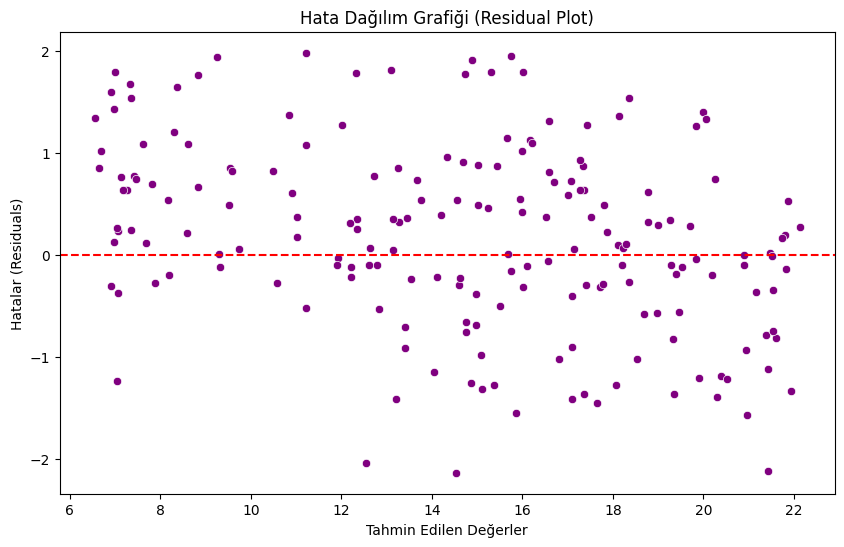

In [ ]:
plt.figure(figsize=(10, 6))
residuals = Y - y_pred
sns.scatterplot(x=y_pred, y=residuals, color="purple")
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Hata Dağılım Grafiği (Residual Plot)")
plt.xlabel("Tahmin Edilen Değerler")
plt.ylabel("Hatalar (Residuals)")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(Y, y_pred)
mse = mean_squared_error(Y, y_pred)
rmse = np.sqrt(mse)

print(f"--- Model Performans Metrikleri ---")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

--- Model Performans Metrikleri ---
MAE: 0.7400
MSE: 0.8517
RMSE: 0.9229


In [ ]:
# Bağımsız değişkenleri (TV, Radio, Newspaper) ve bağımlı değişkeni (Sales) seçme
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

# Modeli kurma ve eğitme
reg_model = LinearRegression().fit(X, y)

# Katsayıları (Weights) ve Sabit Terimi (Bias) yazdırma
print(f"Sabit Terim (b): {reg_model.intercept_:.4f}")
print(f"Katsayılar (w1, w2, w3): {reg_model.coef_}")

Sabit Terim (b): 7.0836
Katsayılar (w1, w2, w3): [0.03064201 0.11519153 0.00017117]


In [ ]:
# Tahmin yapma
y_pred = reg_model.predict(X)

# Hata metriklerini hesaplama
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.6815
MSE: 0.7229
RMSE: 0.8502


In [ ]:
# Yeni gözlem: TV=30, Radio=10, Newspaper=40
yeni_veri = [[30], [10], [40]]
yeni_veri = pd.DataFrame(dict(zip(X.columns, yeni_veri))) # Sütun isimleriyle eşleştirme

tahmin = reg_model.predict(yeni_veri)
print(f"Tahmin Edilen Satış: {tahmin[0]:.2f}")

Tahmin Edilen Satış: 9.16


In [ ]:
# R-Kare değerini hesaplama
r_squared = reg_model.score(X, y)

print(f"R-Kare (R-Squared) Değeri: {r_squared:.4f}")
print(f"Model, satışlardaki değişimin %{r_squared*100:.2f}'sini açıklayabiliyor.")

R-Kare (R-Squared) Değeri: 0.9603
Model, satışlardaki değişimin %96.03'sini açıklayabiliyor.


In [ ]:
# Katsayıları bir tablo olarak görelim
coefficients = pd.DataFrame(reg_model.coef_, X.columns, columns=['Katsayı (Coefficient)'])
print(coefficients.sort_values(by='Katsayı (Coefficient)', ascending=False))

           Katsayı (Coefficient)
Radio                       0.12
TV                          0.03
Newspaper                   0.00


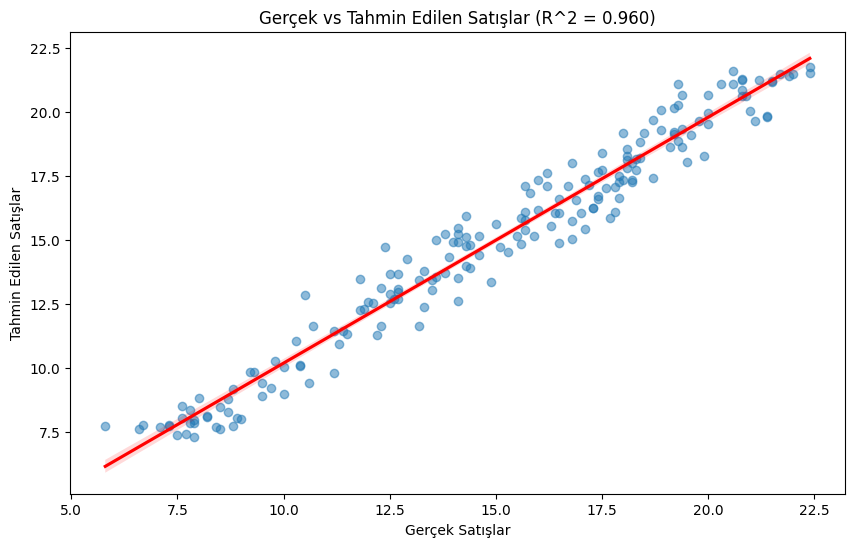

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel("Gerçek Satışlar")
plt.ylabel("Tahmin Edilen Satışlar")
plt.title(f"Gerçek vs Tahmin Edilen Satışlar (R^2 = {r_squared:.3f})")
plt.show()

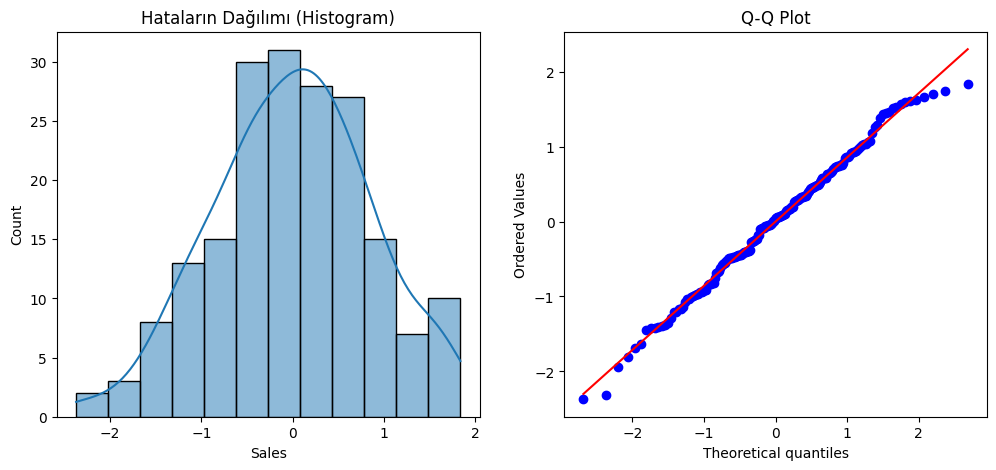

Shapiro-Wilk Testi p-değeri: 0.4538


In [ ]:
import scipy.stats as stats

# Hataları hesaplayalım
residuals = y - y_pred

# Görsel Kontrol: Histogram ve QQ Plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(residuals, kde=True, ax=ax[0])
ax[0].set_title("Hataların Dağılımı (Histogram)")

# QQ Plot
stats.probplot(residuals, dist="norm", plot=ax[1])
ax[1].set_title("Q-Q Plot")

plt.show()

# İstatistiksel Kontrol: Shapiro-Wilk Testi
# p-value > 0.05 ise normal dağılıma uygundur diyebiliriz.
p_value = stats.shapiro(residuals)[1]
print(f"Shapiro-Wilk Testi p-değeri: {p_value:.4f}")

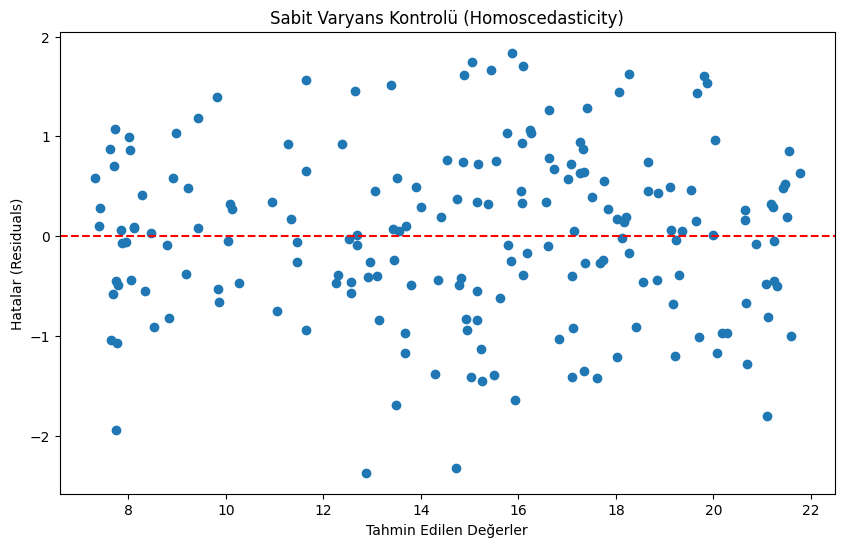

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Tahmin Edilen Değerler')
plt.ylabel('Hatalar (Residuals)')
plt.title('Sabit Varyans Kontrolü (Homoscedasticity)')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Değişken"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

    Değişken       VIF
0         TV 995058.86
1      Radio 995049.02
2  Newspaper      2.30


In [ ]:
import numpy as np

# Bağımlı ve bağımsız değişkenleri logaritmik olarak dönüştürme
df['log_Sales'] = np.log1p(df['Sales'])
df['log_TV'] = np.log1p(df['TV'])
df['log_Radio'] = np.log1p(df['Radio'])

# Yeni model için değişken seçimi
X_log = df[['log_TV', 'log_Radio']]
y_log = df['log_Sales']

# Modeli eğitme
log_model = LinearRegression().fit(X_log, y_log)

print(f"Yeni R-Kare (Log-Model): {log_model.score(X_log, y_log):.4f}")

Yeni R-Kare (Log-Model): 0.9496


In [ ]:
# Tahmin yapma
log_pred = log_model.predict(X_log)

# Orijinal ölçeğe geri dönme (Geri dönüşüm)
y_pred_original = np.expm1(log_pred)
y_actual_original = np.expm1(y_log)

# Yeni Hata Metrikleri
rmse_log = np.sqrt(mean_squared_error(y_actual_original, y_pred_original))
print(f"Log Dönüşümlü Model RMSE: {rmse_log:.4f}")

Log Dönüşümlü Model RMSE: 0.9607


In [ ]:
# Katsayıları (Esneklikleri) alma
# Log-log modelinde katsayılar doğrudan % değişim etkisini verir
coefficients_log = pd.DataFrame(log_model.coef_, X_log.columns, columns=['Esneklik (Elasticity)'])

# Katsayıları büyükten küçüğe sıralayalım
print("--- Reklam Kanallarının Yüzdesel Verimlilik Analizi ---")
print(coefficients_log.sort_values(by='Esneklik (Elasticity)', ascending=False))

--- Reklam Kanallarının Yüzdesel Verimlilik Analizi ---
           Esneklik (Elasticity)
log_Radio                   1.96
log_TV                     -1.46


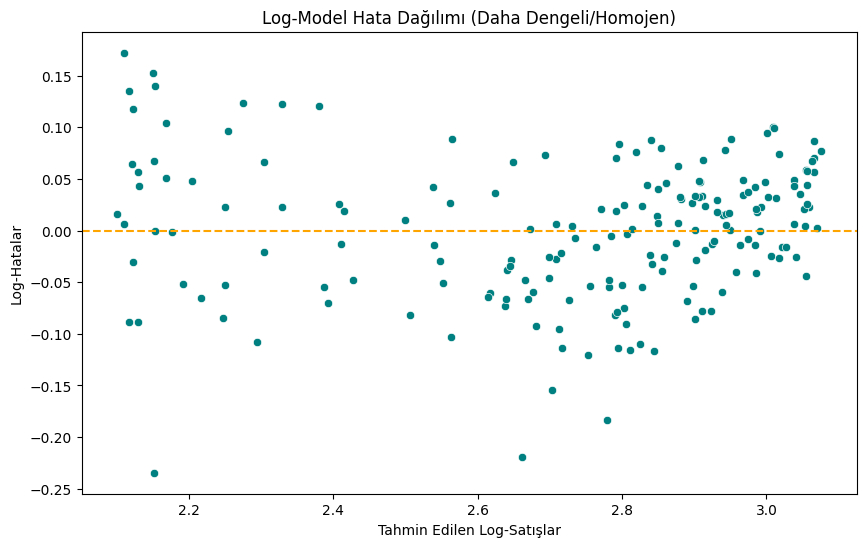

In [ ]:
plt.figure(figsize=(10, 6))
log_residuals = y_log - log_pred
sns.scatterplot(x=log_pred, y=log_residuals, color="teal")
plt.axhline(y=0, color='orange', linestyle='--')
plt.title("Log-Model Hata Dağılımı (Daha Dengeli/Homojen)")
plt.xlabel("Tahmin Edilen Log-Satışlar")
plt.ylabel("Log-Hatalar")
plt.show()

In [ ]:
from scipy.optimize import minimize

# Toplam bütçe kısıtı (Örn: 100 birim)
TOPLAM_BUTCE = 100

# Katsayılarımızı modelden alalım
b0 = log_model.intercept_
w_tv, w_radio = log_model.coef_

# Maksimize edilecek fonksiyon (Eksi ile çarparak minimize ediyoruz)
def objective(x):
    tv, radio = x[0], x[1]
    # np.log1p kullanıldığı için x+1 üzerinden hesaplıyoruz
    return -(b0 + w_tv * np.log1p(tv) + w_radio * np.log1p(radio))

# Kısıt fonksiyonu: tv + radio <= BUTCE
def constraint(x):
    return TOPLAM_BUTCE - (x[0] + x[1])

cons = {'type': 'ineq', 'fun': constraint}
bnds = ((0, TOPLAM_BUTCE), (0, TOPLAM_BUTCE)) # Harcamalar negatif olamaz

# Başlangıç tahmini (Eşit dağılım)
x0 = [TOPLAM_BUTCE/2, TOPLAM_BUTCE/2]

# Optimizasyonu çalıştır
sol = minimize(objective, x0, method='SLSQP', bounds=bnds, constraints=cons)

opt_tv, opt_radio = sol.x
print(f"--- Optimum Bütçe Dağılımı (Toplam: {TOPLAM_BUTCE}) ---")
print(f"TV Harcaması: {opt_tv:.2f}")
print(f"Radio Harcaması: {opt_radio:.2f}")

--- Optimum Bütçe Dağılımı (Toplam: 100) ---
TV Harcaması: 0.00
Radio Harcaması: 100.00


In [ ]:
# Modelin standart hatasını (Residual Standard Error) hesaplayalım
mse = mean_squared_error(y_log, log_pred)
rmse_log = np.sqrt(mse)

n_simulations = 10000
simulated_sales = []

# Belirlenen optimum bütçe üzerinden simülasyon (Örn: TV=70, Radio=30)
for _ in range(n_simulations):
    # Katsayılara ve hata terimine rastgele gürültü ekliyoruz
    noise = np.random.normal(0, rmse_log)
    prediction_log = b0 + w_tv * np.log1p(70) + w_radio * np.log1p(30) + noise
    simulated_sales.append(np.expm1(prediction_log))

# Sonuçları analiz edelim
simulated_sales = np.array(simulated_sales)

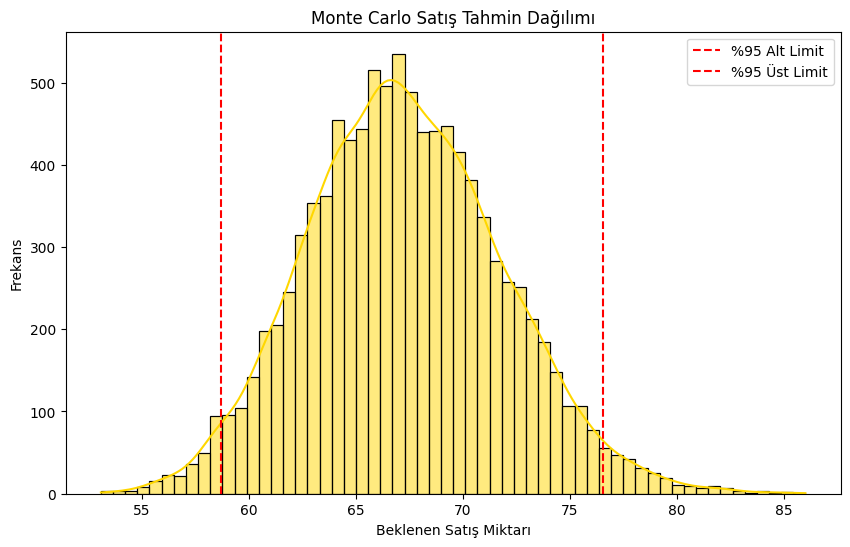

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(simulated_sales, kde=True, color="gold")
plt.axvline(np.percentile(simulated_sales, 2.5), color='red', linestyle='--', label='%95 Alt Limit')
plt.axvline(np.percentile(simulated_sales, 97.5), color='red', linestyle='--', label='%95 Üst Limit')
plt.title("Monte Carlo Satış Tahmin Dağılımı")
plt.xlabel("Beklenen Satış Miktarı")
plt.ylabel("Frekans")
plt.legend()
plt.show()